Mount to Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


Import Libraries

In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint, ReduceLROnPlateau


Load Dataset for Preprocessing

In [3]:
TRAIN_PATH = '/content/gdrive/MyDrive/dataset/Training'
TEST_PATH = '/content/gdrive/MyDrive/dataset/Testing'

IMAGE_SIZE = 150

In [4]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Initialize lists to store images and labels
X_train = []
y_train = []

labels = ['glioma_tumor','no_tumor','meningioma_tumor','pituitary_tumor']

print(f"Preprocessing training data from: {TRAIN_PATH}")
for i in labels:
    folderPath = os.path.join(TRAIN_PATH, i)
    if not os.path.exists(folderPath):
        print(f"Warning: Training subfolder {folderPath} does not exist. Skipping.")
        continue
    for j in tqdm(os.listdir(folderPath), desc=f"Loading {i} training images"):
        img = cv2.imread(os.path.join(folderPath, j))
        if img is None:
            print(f"Warning: Could not read image {os.path.join(folderPath, j)}. Skipping.")
            continue
        img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
        X_train.append(img)
        y_train.append(i)

print(f"\nPreprocessing testing data from: {TEST_PATH}")
for i in labels:
    folderPath = os.path.join(TEST_PATH, i)
    if not os.path.exists(folderPath):
        print(f"Warning: Testing subfolder {folderPath} does not exist. Skipping.")
        continue
    for j in tqdm(os.listdir(folderPath), desc=f"Loading {i} testing images"):
        img = cv2.imread(os.path.join(folderPath, j))
        if img is None:
            print(f"Warning: Could not read image {os.path.join(folderPath, j)}. Skipping.")
            continue
        img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
        X_train.append(img)
        y_train.append(i)

# Convert lists to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"\nFinished preprocessing. X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

Preprocessing training data from: /content/gdrive/MyDrive/dataset/Training


Loading pituitary_tumor training images: 100%|██████████| 827/827 [00:17<00:00, 47.14it/s] 



Preprocessing testing data from: /content/gdrive/MyDrive/dataset/Testing


Loading pituitary_tumor testing images: 100%|██████████| 74/74 [00:18<00:00,  4.09it/s]


Finished preprocessing. X_train shape: (3264, 150, 150, 3), y_train shape: (3264,)


Data visualization

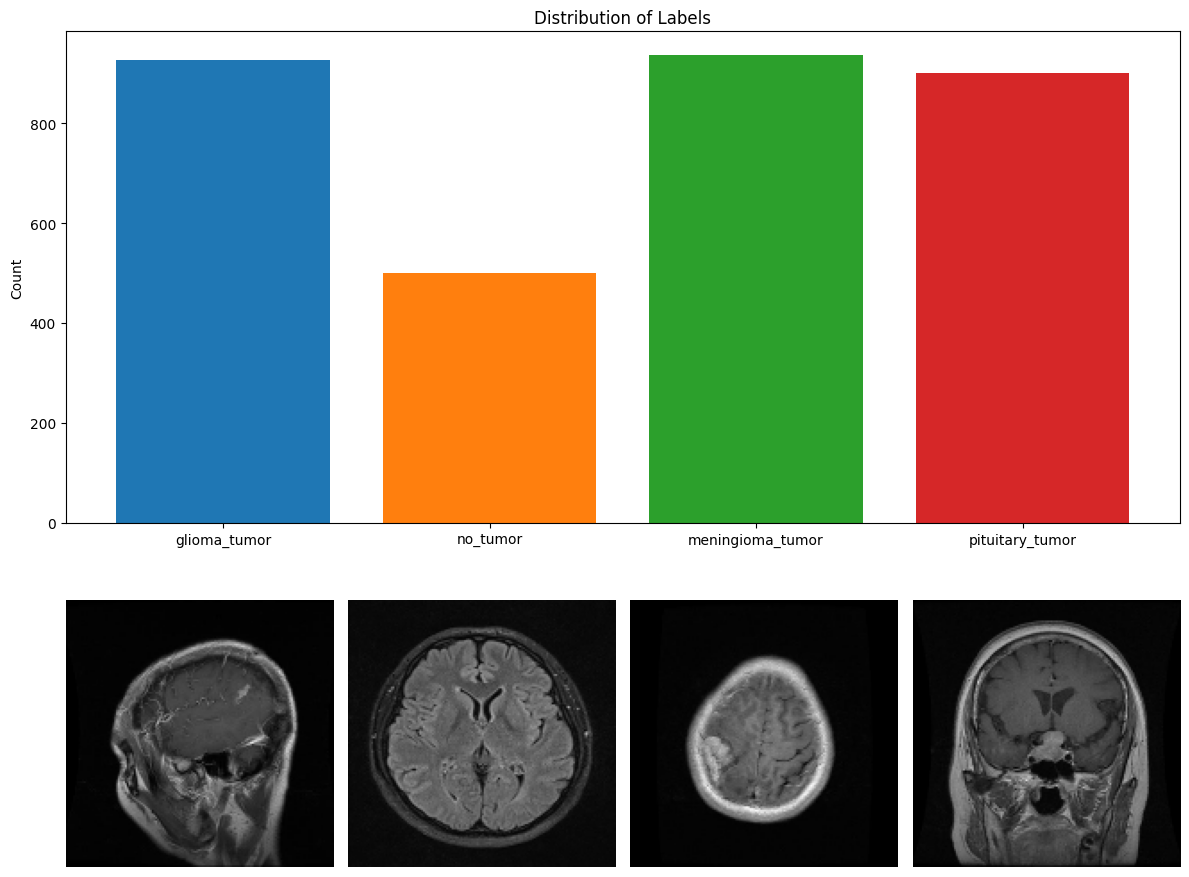

In [5]:


# Calculate the bar plot for each label
label_counts = {label: np.sum(y_train == label) for label in labels}

# Plot the bar plot and sample images in one chart
plt.figure(figsize=(12, 10)) # Increased figure size for better visualization

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"] # Using default matplotlib colors or similar

# Plot the histogram
plt.subplot(2, 1, 1)
bars = plt.bar(label_counts.keys(), label_counts.values(), color=colors)
# mplcyberpunk.add_bar_gradient(bars=bars) # Removed mplcyberpunk dependency
plt.ylabel('Count')
plt.title('Distribution of Labels')

# Plot sample images from each label
k = 0
for i in labels:
    j = 0
    while True:
        # Ensure index j is within bounds of X_train and y_train
        if j < len(y_train) and y_train[j] == i:
            plt.subplot(2, 4, k + 5)
            plt.imshow(X_train[j])
            plt.axis('off')
            k += 1
            break
        j += 1
        # Add a safeguard to prevent infinite loops if a label has no images
        if j >= len(y_train):
            print(f"Warning: No images found for label: {i}")
            break

plt.tight_layout()
plt.show()

### Dataset Split: Train and Test

In [6]:
X_train, y_train = shuffle(X_train,y_train, random_state=101)

X_train,X_test,y_train,y_test = train_test_split(X_train,y_train, test_size=0.1,random_state=101)

### One-Hot Encoding Labels

In [7]:
import numpy as np
import tensorflow as tf

# Safely encode labels to categorical only if they are not already one-hot encoded
if len(np.array(y_train).shape) == 1:
    y_train_new = [labels.index(i) for i in y_train]
    y_train = tf.keras.utils.to_categorical(y_train_new, num_classes=len(labels))

if len(np.array(y_test).shape) == 1:
    y_test_new = [labels.index(i) for i in y_test]
    y_test = tf.keras.utils.to_categorical(y_test_new, num_classes=len(labels))

print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

y_train shape: (2937, 4)
y_test shape: (327, 4)


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# Split validation data manually since model.fit's validation_split doesn't work directly with data generators
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.1, random_state=101)

# Create the ImageDataGenerator with augmentations
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Prepare the generator
datagen.fit(X_train_split)

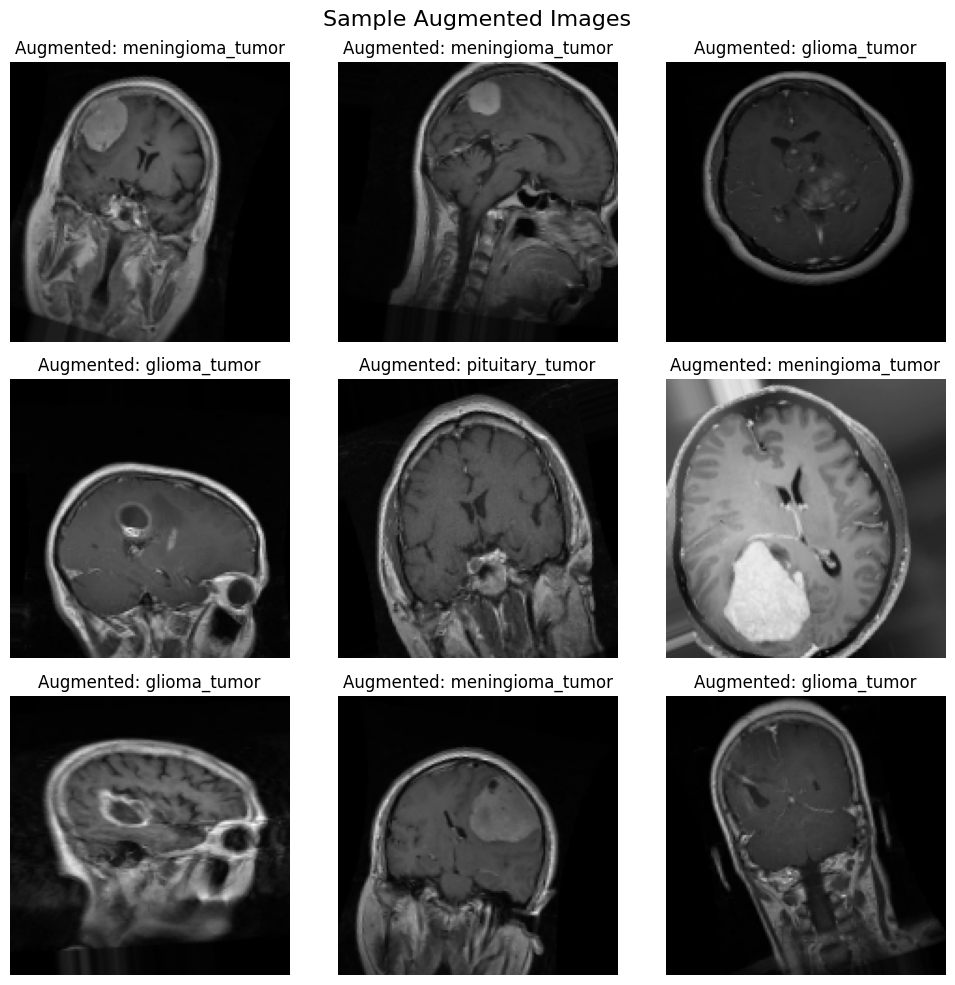

In [9]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Get a batch of augmented images from the generator
aug_iter = datagen.flow(X_train_split, y_train_split, batch_size=9)
aug_images, aug_labels = next(aug_iter)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)

    # The generator outputs float32, we convert to uint8 for visualization
    img = aug_images[i].astype(np.uint8)

    # Convert BGR (from cv2) to RGB for Matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)

    # Get the label string from the one-hot encoded label
    label_index = np.argmax(aug_labels[i])
    plt.title(f"Augmented: {labels[label_index]}")
    plt.axis('off')

plt.suptitle("Sample Augmented Images", fontsize=16)
plt.tight_layout()
plt.show()

### Build Model: DenseNet121

In [40]:
from sklearn.model_selection import KFold
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# Define K-Fold Cross Validation before building models
k_folds = 5
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=101)

def build_model():
    base_model = tf.keras.applications.DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
    )

    # Leaner, more efficient classification head
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    # Output layer with L2 regularization to prevent overfitting
    outputs = layers.Dense(4, activation='softmax', kernel_regularizer=regularizers.l2(0.01))(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)

    # Compile with a lower learning rate for stable fine-tuning
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    return model

print(f"{k_folds}-Fold Validation setup complete.")

5-Fold Validation setup complete.


In [41]:
import numpy as np
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint, ReduceLROnPlateau

# Arrays to store scores
acc_per_fold = []
loss_per_fold = []

fold_no = 1

# Convert y_train back to categorical labels for splitting if it's one-hot encoded
y_train_labels = np.argmax(y_train, axis=1) if len(y_train.shape) > 1 else y_train

print(f"Starting {k_folds}-fold cross validation...")

for train_index, val_index in kfold.split(X_train, y_train_labels):
    print(f'\nTraining for fold {fold_no} ...')

    # Split data for this fold
    X_fold_train, X_fold_val = X_train[train_index], X_train[val_index]
    y_fold_train, y_fold_val = y_train[train_index], y_train[val_index]

    # Generate a fresh model
    model_cv = build_model()

    # Define callbacks for this specific fold
    tensorboard = TensorBoard(log_dir=f'logs/fold_{fold_no}')
    checkpoint = ModelCheckpoint(f"densenet121_fold_{fold_no}.keras", monitor="val_accuracy",
                                 save_best_only=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=2,
                                  min_delta=0.0001, verbose=1)

    # Train the model
    history = model_cv.fit(
        datagen.flow(X_fold_train, y_fold_train, batch_size=32),
        validation_data=(X_fold_val, y_fold_val),
        epochs=12,
        verbose=1,
        callbacks=[tensorboard, checkpoint, reduce_lr]
    )

    # Evaluate the model on the validation set for this fold
    scores = model_cv.evaluate(X_fold_val, y_fold_val, verbose=0)
    print(f'Score for fold {fold_no}: {model_cv.metrics_names[0]} of {scores[0]:.4f}; {model_cv.metrics_names[1]} of {scores[1]*100:.2f}%')

    acc_per_fold.append(scores[1] * 100)
    loss_per_fold.append(scores[0])

    fold_no += 1

print('\n------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(acc_per_fold)):
    print(f'> Fold {i+1} - Loss: {loss_per_fold[i]:.4f} - Accuracy: {acc_per_fold[i]:.2f}%')
print('------------------------------------------------------------------------')
print('Average scores for all folds:')
print(f'> Accuracy: {np.mean(acc_per_fold):.2f}% (+- {np.std(acc_per_fold):.2f}%)')
print(f'> Loss: {np.mean(loss_per_fold):.4f}')
print('------------------------------------------------------------------------')

Starting 5-fold cross validation...

Training for fold 1 ...
Epoch 1/12
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4381 - loss: 1.8151
Epoch 1: val_accuracy improved from None to 0.67347, saving model to densenet121_fold_1.keras

Epoch 1: finished saving model to densenet121_fold_1.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.5509 - loss: 1.4866 - val_accuracy: 0.6735 - val_loss: 1.1374 - learning_rate: 5.0000e-05
Epoch 2/12
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.7298 - loss: 1.0860
Epoch 2: val_accuracy improved from 0.67347 to 0.81122, saving model to densenet121_fold_1.keras

Epoch 2: finished saving model to densenet121_fold_1.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 16s 219ms/step - accuracy: 0.7471 - loss: 1.0392 - val_accuracy: 0.8112 - val_loss: 0.8997 - learning_rate: 5.0000e-05
Epoch 3/12
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.7949 - loss: 0.9439
Epoch 3: val_accuracy improved from 0.81122 to 0.86735, saving model to densenet121

### Classification Report

In [42]:
from sklearn.metrics import classification_report
import numpy as np
import tensorflow as tf

# You can also load a specific fold's best model if you prefer:
# model = tf.keras.models.load_model('efficientnetB0_fold_5.keras')

# Get model predictions on the test set using the last trained fold model (model_cv)
y_pred = model_cv.predict(X_test)

# Convert one-hot encoded predictions and true labels to class indices
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Generate and print the classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=labels)
print("Classification Report:\n")
print(report)

11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step
Classification Report:

                  precision    recall  f1-score   support

    glioma_tumor       0.95      0.96      0.95        93
        no_tumor       1.00      0.94      0.97        51
meningioma_tumor       0.96      0.91      0.93        96
 pituitary_tumor       0.89      0.97      0.93        87

        accuracy                           0.94       327
       macro avg       0.95      0.94      0.95       327
    weighted avg       0.94      0.94      0.94       327



### Loss and Accuracy Plot

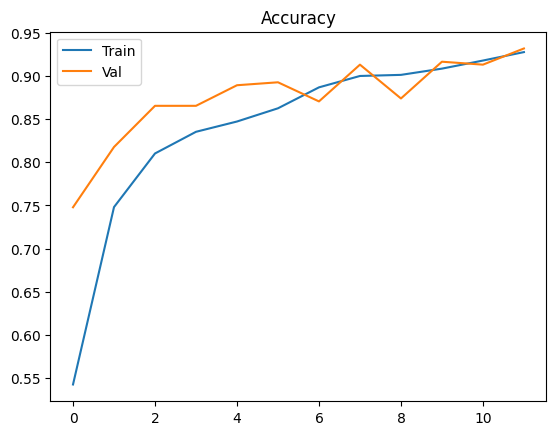

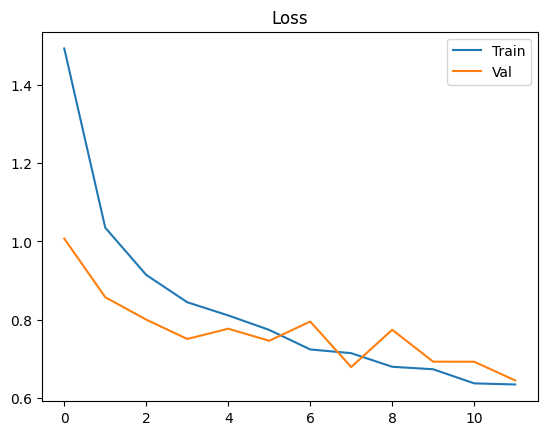

In [43]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Val'])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Val'])
plt.show()

### Confusion Matrix

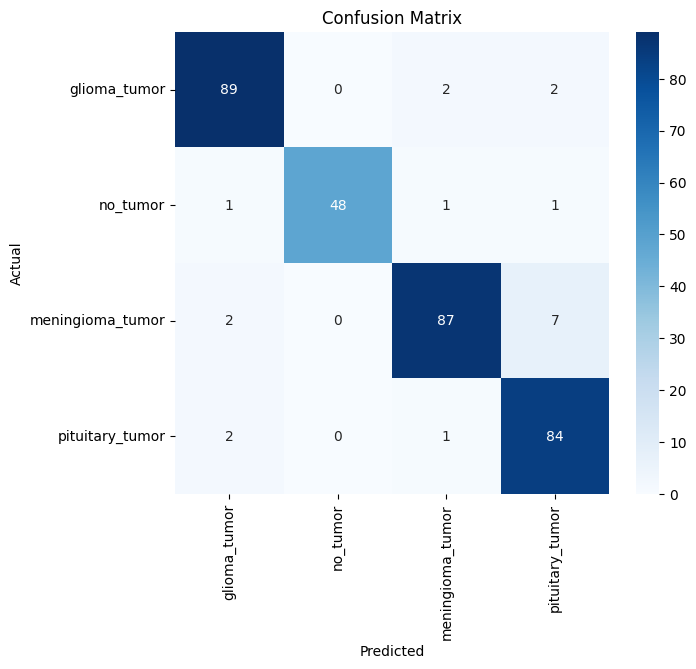

In [44]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

plot_confusion_matrix(y_true_classes, y_pred_classes, labels)

### Receiver Operating Characteristic (ROC) Curve

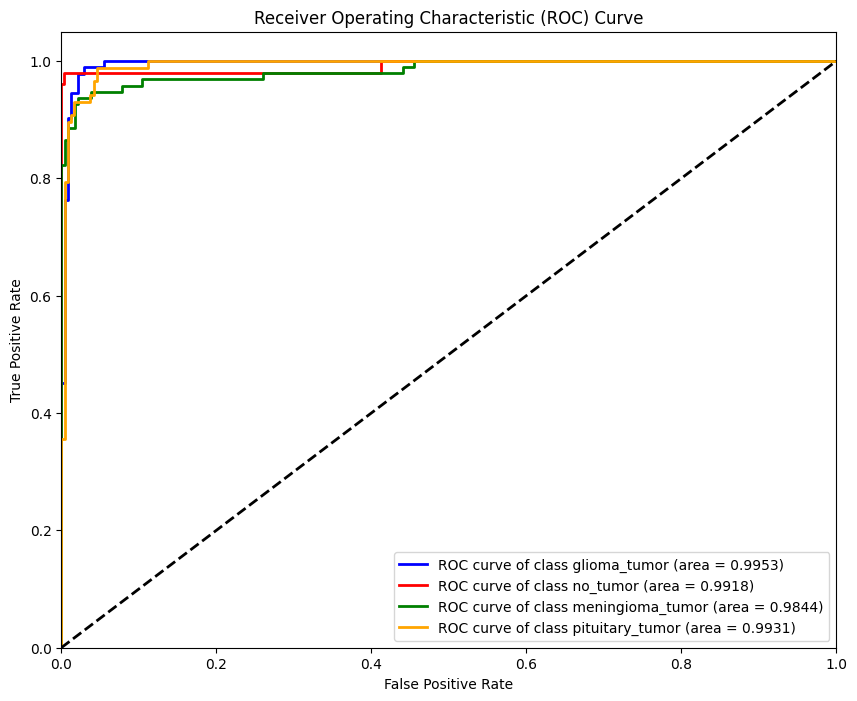

In [45]:
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = len(labels)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.4f})'
             ''.format(labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

### Brain Tumor Detection System

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class_labels = ['glioma_tumor', 'no_tumor', 'meningioma_tumor', 'pituitary_tumor']

def detect_and_display(img_path, model, IMAGE_SIZE=150):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load the image using OpenCV exactly as in training (reads as BGR, [0, 255])
        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))

        img_array = np.expand_dims(img, axis=0)  # Add batch dimension

        # During training, no preprocessing was applied; EfficientNet handles it internally.
        # So we directly pass the array.
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'no_tumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction (convert BGR to RGB for matplotlib)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


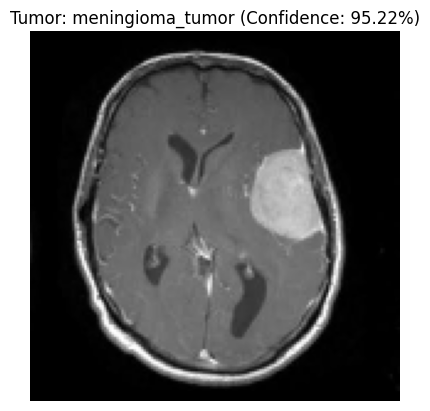

In [47]:
# Example usage
image_path = '/content/gdrive/MyDrive/dataset/Testing/meningioma_tumor/image.jpg'  # Provide the path to your new image
detect_and_display(image_path, model_cv)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


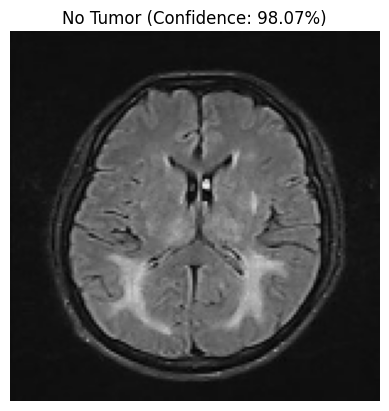

In [53]:
# Example usage
image_path = '/content/gdrive/MyDrive/dataset/Testing/no_tumor/image(10).jpg'  # Provide the path to your new image
detect_and_display(image_path, model_cv)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


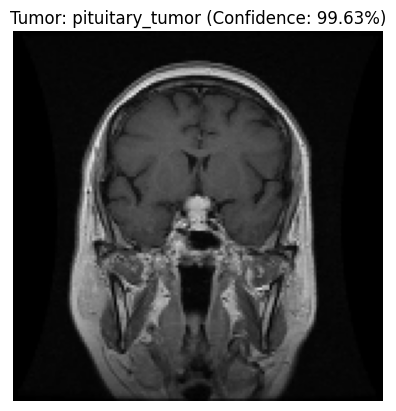

In [49]:
4# Example usage
image_path = '/content/gdrive/MyDrive/dataset/Testing/pituitary_tumor/image.jpg'  # Provide the path to your new image
detect_and_display(image_path, model_cv)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


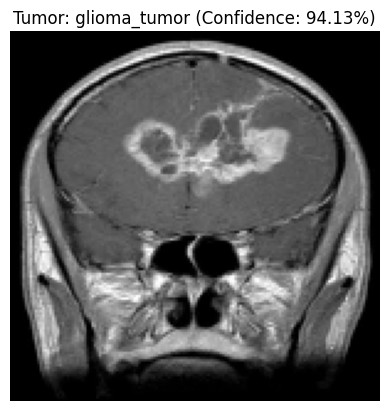

In [52]:
# Example usage
image_path = '/content/gdrive/MyDrive/dataset/Testing/glioma_tumor/image(1).jpg'  # Provide the path to your new image
detect_and_display(image_path, model_cv)